In [2]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [3]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

In [4]:
using JLD2

In [5]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

# Inspecting a single file

In [6]:
f = jldopen("./wrtk_1/d1_k0.0.jld2")

fmetadata = f["metadata"]
dx = fmetadata.L / fmetadata.sN;

Ks = fmetadata.Ks

tmm_params = f["tmm_params"];
Ds = SA[fmetadata.DN1, fmetadata.DN2, fmetadata.DI, fmetadata.DR1, fmetadata.DR2];
results = f["results"];

In [7]:
mean_survivors = map(results) do xx
    mean(xx.fss) do fs
        num_survivors_in_space(fs, 2)
    end
end;

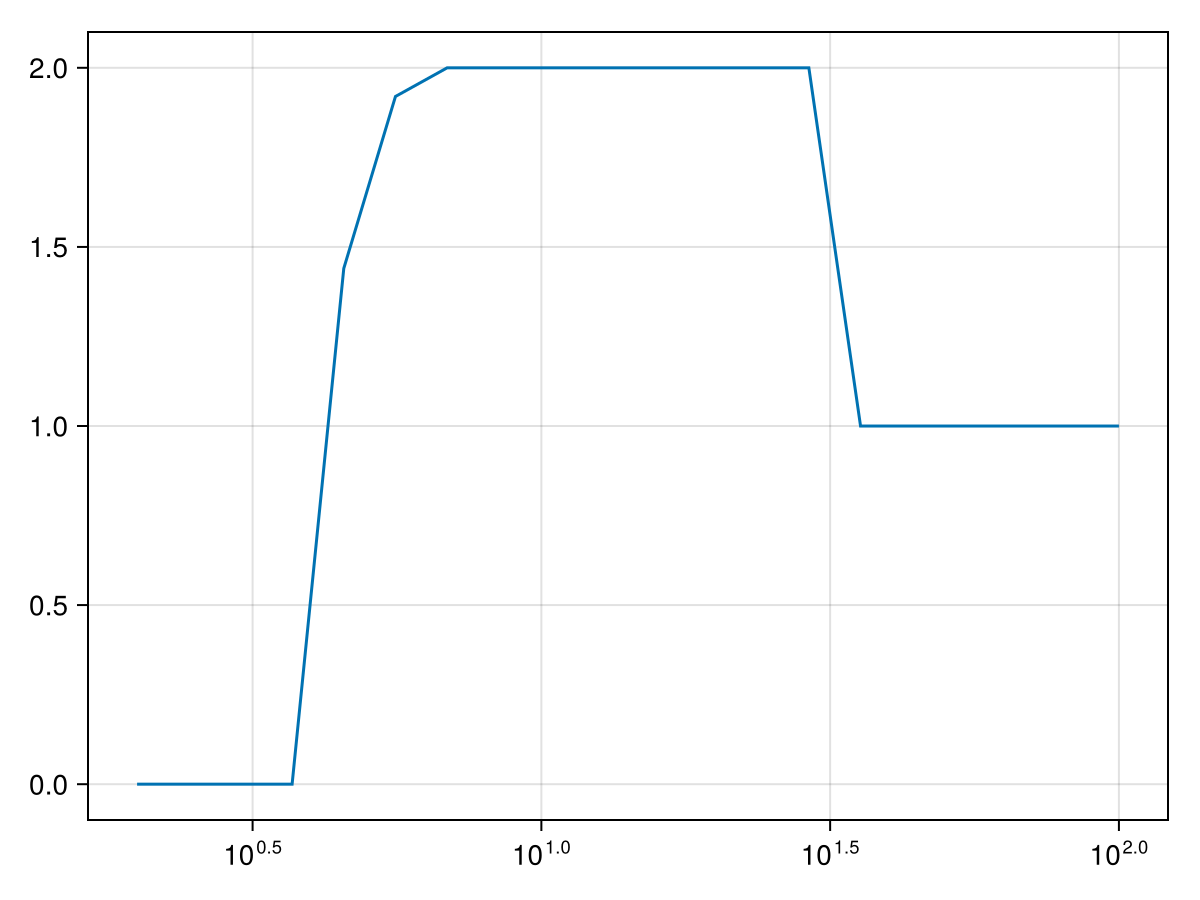

In [8]:
lines(Ks, mean_survivors;
    axis=(; xscale=log10)
)

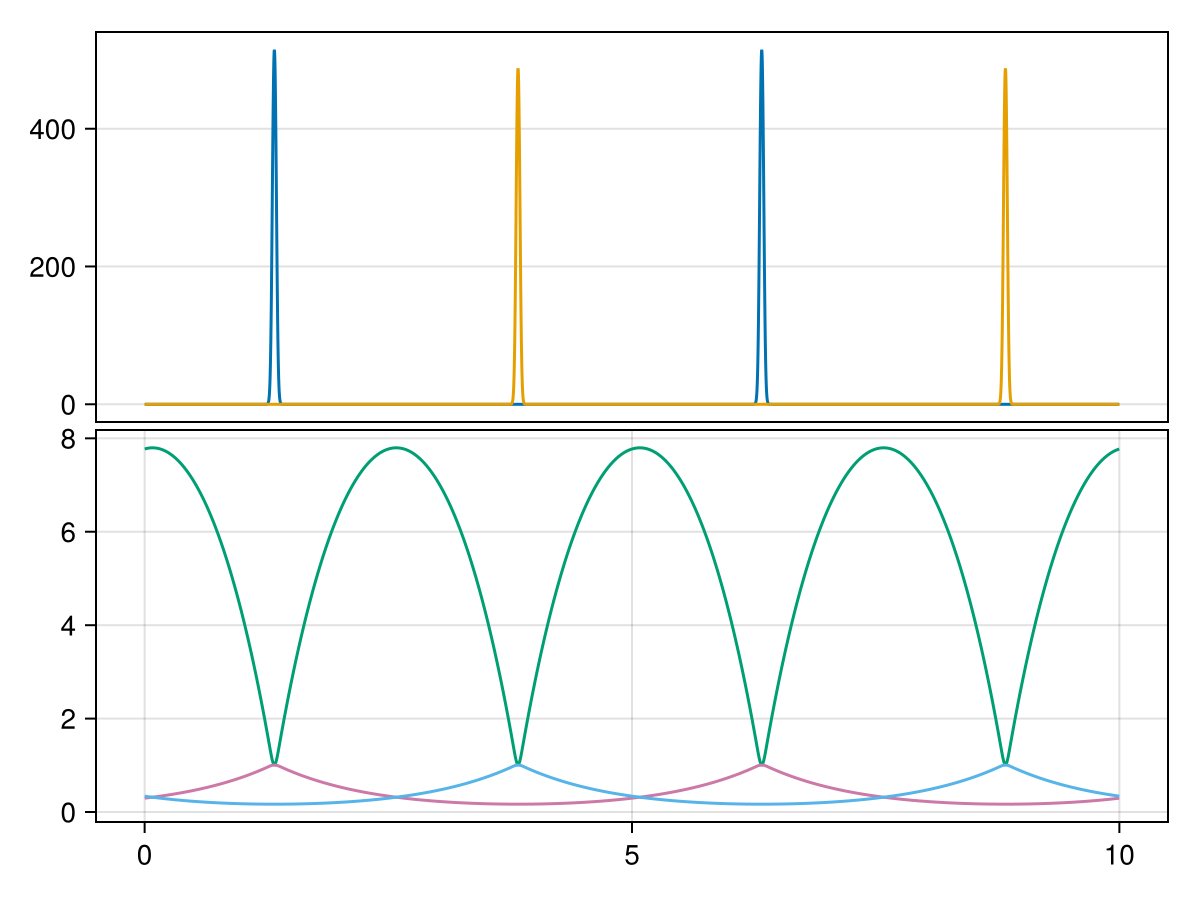

In [28]:
iK = 11
ri = 1
fs = results[iK].fss[ri]
tmm_ps = tmm_params[iK]
mmicrm_ps = tmmsp_to_mmicrm(tmm_ps)
plot_spatial_fs(fs, 2, fmetadata.sN, dx)

In [126]:
means = mean(fs; dims=2)[:,1];
xx = fs[:,667];

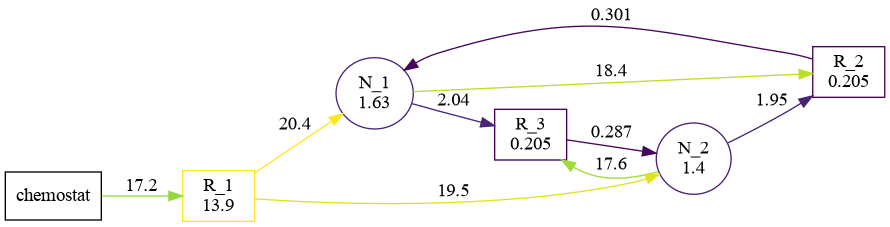

In [127]:
diagram_sfss_v3(mmicrm_ps, means)

# Plotting data from all files

In [11]:
for f in files
    close(f)
end
GC.gc()

LoadError: UndefVarError: `files` not defined

In [5]:
ks = [0.0, 0.1, 0.4, 0.5, 0.6, 0.9, 1.0]
files = map(ks) do k
    jldopen(@sprintf "./wrtk_1/d1_k%.1f.jld2" k)
end;
Ks = files[1]["metadata"].Ks;

## Making reports of final states

In [30]:
km2 = SSMCMain.ModifiedMiCRM.MinimalModelV2.fr2_km2(4.77, 1., 1., 1.)
km2 = SSMCMain.ModifiedMiCRM.MinimalModelV2.fr2_km2(17.2, 1., 1., 1.)
L = SSMCMain.ModifiedMiCRM.MinimalModelV2.ksquared_to_L(km2)
@show L floor(10 / L);

L = 0.28914420313963934
floor(10 / L) = 34.0


In [15]:
for i in 1:length(files)
    fig = plot_many_final_states(files[i], 10, 4:2:length(Ks))
    # fig = plot_many_final_states(files[i], 3, 4:4:length(Ks))
    Label(fig[0,:], (@sprintf "This is for k=%.3g (0 is pure competition, 1 is cosmo)." ks[i]); fontsize=30)
    Makie.save("./wrtk_1/fs_$i.pdf", fig)
end

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

## Number of suvivors vs K

In [25]:
mean_surv_all = map(files) do f
    map(f["results"]) do xx
        # @show countmap(xx.retcodes)
        mean(xx.fss) do fs
            num_survivors_in_space(fs, 2)
        end
    end
end;

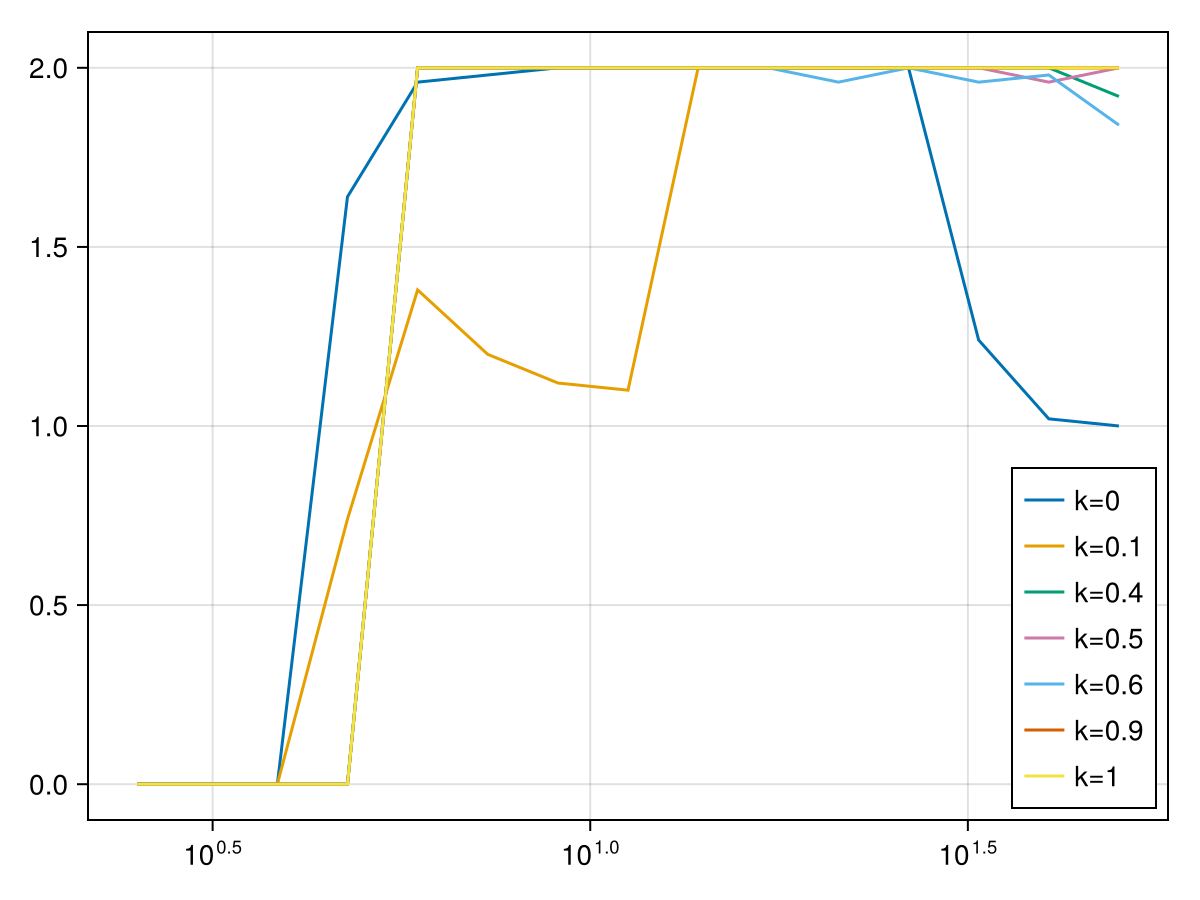

In [28]:
fig = Figure()
ax = Axis(fig[1,1];
    xscale=log10,
)
for (k, xx) in zip(ks, mean_surv_all)
    lines!(ax, Ks, xx; label=(@sprintf "k=%.3g" k))
end
axislegend(ax; position=:rb)

fig


# Plotting outcomes with K

In [13]:
# f = jldopen("../../cluster_env/runs/compmm_sines1/rslts2.jld2")
f = jldopen("../../cluster_env/runs/compmm_sines1/rslts4_m_c_0.5.jld2")
# md = f["params"]
Ks = f["Ks"]
results = f["results"]
num_repeats = length(f["results"][1].outcomes)
nothing

In [11]:
md

(m1 = 0.9, c1 = 0.9, l1 = 1.0, m2 = 1.0, c2 = 1.0, l2 = 1.0, DI = 1.0, DR1 = 1.0, DR2 = 1.0, DN1 = 1.0e-6, DN2 = 1.0e-6, numrepeats = 50, T = 1.0e8, L = 10, sN = 10000, meanN0 = 1.0, numwaves = 100, waveampfactor = 20.0)

In [14]:
out_cms = map(f["results"]) do x
    countmap(x.outcomes)
end

num_ext = []
num_coex = []
num_S1 = []
num_S2 = []
for cm in out_cms
    push!(num_ext, get(cm, CMMsSpatialOutcome.Extinction, 0))
    push!(num_coex, get(cm, CMMsSpatialOutcome.Coexistence, 0))
    push!(num_S1, get(cm, CMMsSpatialOutcome.S1Only, 0))
    push!(num_S2, get(cm, CMMsSpatialOutcome.S2Only, 0))
end
@assert all((num_ext .+ num_coex .+ num_S1 .+ num_S2) .== num_repeats)

In [15]:
using ColorSchemes

In [16]:
using Colors

In [17]:
ii = 2
col1 = ColorSchemes.Reds[end-ii]
col2 = ColorSchemes.Blues[end-ii]
col3 = colorant"#b53296";

In [18]:
show(hex.([col1, col2]))

["CB181D", "2171B5"]

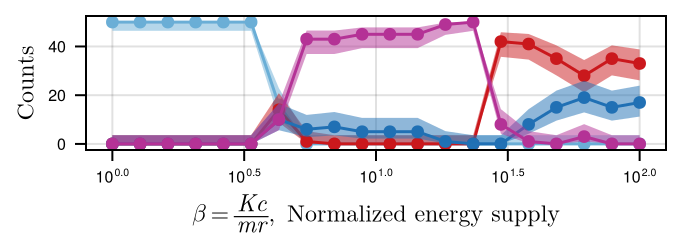

In [20]:
fig = Figure(;
    # size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.3),
)
ax = Axis(fig[1,1];
    xscale=log10,
    xlabel=L"\beta=\frac{Kc}{mr},\enspace\text{Normalized energy supply}",
    ylabel=L"\text{Counts}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)

plot_binom_sample!(ax, Ks, num_ext, num_repeats;
    color=PaperColors.extinct1(),
    label="Extinction",
)
plot_binom_sample!(ax, Ks, num_S1, num_repeats;
    color=col1,
    label="Extinction",
)
plot_binom_sample!(ax, Ks, num_S2, num_repeats;
    color=col2,
    label="Extinction",
)
plot_binom_sample!(ax, Ks, num_coex, num_repeats;
    color=col3,
    label="Extinction",
)

# vlines!(ax, [Ks[4], Ks[11]];
    # color=:black,
    # linestyle=:dash,
# )

Makie.save("../../figures/fig4_cmms/poster_props.pdf", fig)

fig

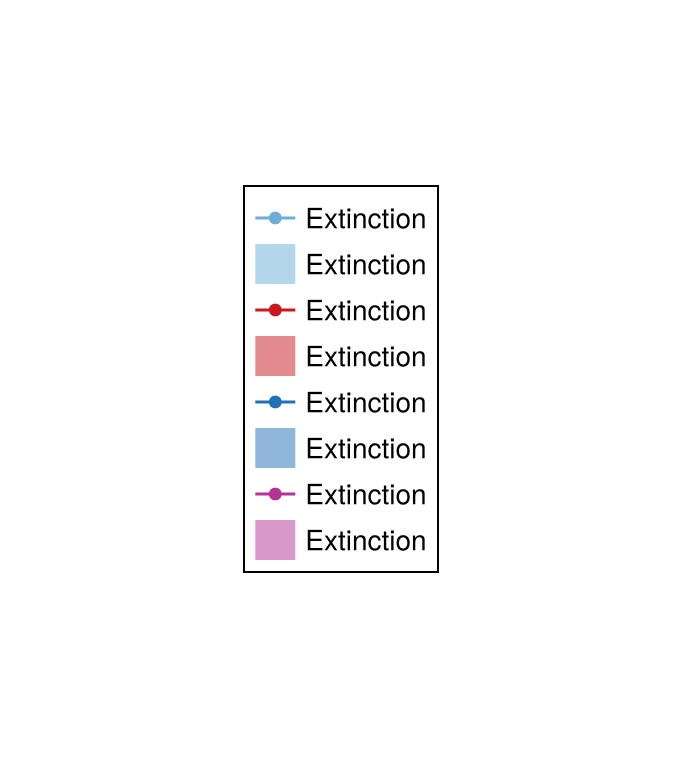

In [56]:
fig = Figure(;
    # size=(double_col_width * 0.45, (double_col_width / golden_ratio) * 0.52),
    figure_padding=(8., 8., 8., 8.),
    size=(double_col_width * 0.5, (double_col_width / golden_ratio) * 0.9),
)
Legend(fig[1,1], ax)
Makie.save("../../figures/fig4_cmms/legend_base.pdf", fig)
fig

# Plotting example spatial structure

In [236]:
f = jldopen("../../cluster_env/runs/compmm_sines1/rslts2.jld2")
# f = jldopen("../../cluster_env/runs/compmm_sines1/rslts4_m_c_0.5.jld2")
md = f["params"]
Ks = f["Ks"]
results = f["results"]
num_repeats = length(f["results"][1].outcomes)
nothing

In [249]:
# ii = 7
ii = 10 # for crazy final states
@show Ks[ii] countmap(results[ii].outcomes)
fs = results[ii].fss[1];

Ks[ii] = 26.366508987303583
countmap((results[ii]).outcomes) = Dict{Main.CMMsSpatialOutcome.T, Int64}(Main.CMMsSpatialOutcome.Coexistence => 50)


In [250]:
cmmps = CMMsParams(;
    K=Ks[ii],
    m1=md.m1, c1=md.c1, l1=md.l1,
    m2=md.m2, c2=md.c2, l2=md.l2,
)
Ds = [md.DN1, md.DN2, md.DI, md.DR1, md.DR2];
ps = BSMMiCRMParams(
    cmmsp_to_mmicrm(cmmps),
    Ds,
    make_cartesianspace_smart(1; dx=md.L / md.sN),
    nthreads()
);

xx = zeros(size(fs));
maximum(abs, smmicrmfunc!(xx, fs, ps))

4.5051208985569247e-8

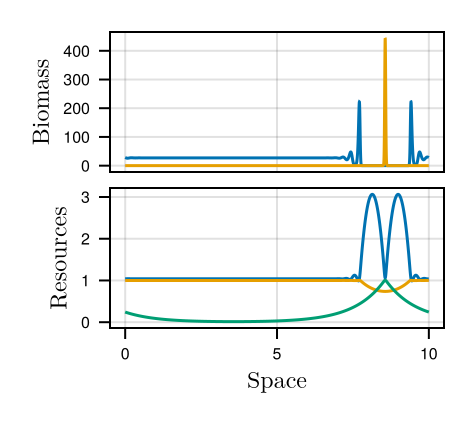

In [251]:
fig = Figure(;
    size=(double_col_width * 0.35, (double_col_width / golden_ratio) * 0.5),
)
ax1 = Axis(fig[1,1];
    # xscale=log10,
    # yscale=log10
    xlabel=L"\text{Space}",
    ylabel=L"\text{Biomass}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)
ax2 = Axis(fig[2,1];
    # xscale=log10,
    # yscale=log10
    xlabel=L"\text{Space}",
    ylabel=L"\text{Resources}",
    xlabelsize=8fontsize_ltex_pt,
    ylabelsize=8fontsize_ltex_pt,
    xticklabelsize=6fontsize_pt,
    yticklabelsize=6fontsize_pt,
)
linkxaxes!(ax1, ax2)
hidexdecorations!(ax1; grid=false)
rowgap!(fig.layout, 8.)

dx = md.L / md.sN
xs = ((1:md.sN) .- 1) .* dx;

lines!(ax1, xs, fs[1,:];
    # color=community_color,
)
lines!(ax1, xs, fs[2,:];
    # color=community_color,
)

lines!(ax2, xs, fs[3,:];
    # color=influx_resource_color,
)
lines!(ax2, xs, fs[4,:];
    # color=crossfed_resource_color,
)
lines!(ax2, xs, fs[5,:];
    # color=crossfed_resource_color,
)

# ax1.xticks = 0:5
# ax2.xticks = 0:5

# Makie.save("../../figures/fig4_cmms/fs_lowK_base.pdf", fig)

fig

In [245]:
# Test whether this is a legitimate final state
cmmps = CMMsParams(;
    K=Ks[ii],
    m1=md.m1, c1=md.c1, l1=md.l1,
    m2=md.m2, c2=md.c2, l2=md.l2,
)
Ds = [md.DN1, md.DN2, md.DI, md.DR1, md.DR2];
ps = BSMMiCRMParams(
    cmmsp_to_mmicrm(cmmps),
    Ds,
    make_cartesianspace_smart(1; dx=md.L / md.sN),
    nthreads()
);

xx = zeros(size(fs));
@sprintf "Maximum residual is %.5g" maximum(abs, smmicrmfunc!(xx, fs, ps))

"Maximum residual is 4.5051e-08"

# Adding params because I forgot before

In [7]:
close(f)
GC.gc()

In [8]:
xx = (;
    # Ks,
    m1=0.9, c1=0.9, l1=1.,
    m2=1.0, c2=1.0, l2=1.,
    DI=1., DR1=1., DR2=1.,
    DN1=1e-6, DN2=1e-6,
    numrepeats=50, T=1e8, L=10, sN=5000,
    meanN0=1., numwaves=100, waveampfactor=50.,
)

(m1 = 0.9, c1 = 0.9, l1 = 1.0, m2 = 1.0, c2 = 1.0, l2 = 1.0, DI = 1.0, DR1 = 1.0, DR2 = 1.0, DN1 = 1.0e-6, DN2 = 1.0e-6, numrepeats = 50, T = 1.0e8, L = 10, sN = 5000, meanN0 = 1.0, numwaves = 100, waveampfactor = 50.0)

In [9]:
f = jldopen("../../cluster_env/runs/compmm_sines1/rslts3.jld2", "r+")
delete!(f, "params")
f["params"] = xx
close(f)